Raz Leisbon & Demain Stoianov

# Starter notebook – Supervised learning (fly pairs)

This notebook **loads the data and shows how it is organized**. It does not solve any of the tasks.
Use it as the starting point of your own notebook: keep what is useful, delete the rest.

The full task description is in [`README.md`](README.md) in this folder.

**Contents**
1. Load the data
2. What the columns mean
3. Chunks of 150 frames
4. A first look at one chunk
5. Checking your prediction files (Task 7)

## 0. Setup

In [1]:
# Setup: works both on your own computer and in Google Colab.
# In Colab, this cell downloads the course repository (with the data) and moves into it.
import os, sys

REPO_URL = "https://github.com/deutschlab/computational-ethology-final-project.git"   # course repository
PART = "supervised"

if "google.colab" in sys.modules and not os.path.exists("data"):
    !git clone --depth 1 {REPO_URL} course_repo
    %cd course_repo/{PART}

print("Data files:", sorted(os.listdir("data")))

Cloning into 'course_repo'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 25 (delta 1), reused 15 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 133.20 MiB | 17.86 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/course_repo/supervised
Data files: ['blind_test.csv.gz', 'test.csv.gz', 'test_short_labels.csv', 'train.csv.gz', 'train_short_labels.csv']


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the data

The large files are compressed (`.csv.gz`). pandas reads them directly, no need to unzip.
The first column of each file only holds the row number, so we use it as the index (`index_col=0`).
Loading takes a few seconds.

In [ ]:
train = pd.read_csv("data/train.csv.gz", index_col=0)
test = pd.read_csv("data/test.csv.gz", index_col=0)
blind_test = pd.read_csv("data/blind_test.csv.gz", index_col=0)

train_short_labels = pd.read_csv("data/train_short_labels.csv", index_col=0)
test_short_labels = pd.read_csv("data/test_short_labels.csv", index_col=0)

for name, df in [("train", train), ("test", test), ("blind_test", blind_test),
                 ("train_short_labels", train_short_labels), ("test_short_labels", test_short_labels)]:
    print(f"{name:20s} {df.shape[0]:>7,} rows x {df.shape[1]} columns")

train                240,000 rows x 53 columns
test                 120,000 rows x 53 columns
blind_test           120,000 rows x 52 columns
train_short_labels     1,600 rows x 1 columns
test_short_labels        800 rows x 1 columns


In [ ]:
train.head()

,M_X_head,M_X_thorax,M_X_abdomen,M_X_wingL,M_X_wingR,M_X_forelegL4,M_X_forelegR4,M_X_midlegL4,M_X_midlegR4,M_X_hindlegL4,...,F_Y_wingR,F_Y_forelegL4,F_Y_forelegR4,F_Y_midlegL4,F_Y_midlegR4,F_Y_hindlegL4,F_Y_hindlegR4,F_Y_eyeL,F_Y_eyeR,Label
0,694.960938,685.045044,675.260254,671.459534,665.264587,715.462463,673.168579,715.178955,647.450012,709.321838,...,555.512878,571.654297,533.848877,579.904480,527.762512,577.780029,533.690308,561.931702,541.782837,0
1,694.967041,685.047974,675.229126,671.465820,665.271851,715.467834,673.179382,715.198059,647.452332,709.343018,...,555.497986,571.643921,533.834412,579.887512,527.750977,577.760132,533.670593,561.919983,541.762695,0
2,694.956177,685.009277,675.196472,671.402344,665.200562,716.843079,673.144531,715.147827,647.362793,709.307251,...,555.471741,571.631348,533.840942,579.897400,527.774536,577.765259,533.682129,561.919922,541.767700,0
3,694.928284,684.998474,675.202332,671.413269,665.194397,716.836975,673.126465,715.158875,647.345154,709.322815,...,555.480652,571.627014,533.849243,579.898621,527.783630,577.783142,533.713196,561.927979,541.774902,0
4,694.943848,685.027954,675.211670,671.436401,665.233643,716.853577,673.142212,715.185974,647.410583,709.350220,...,555.463867,571.645020,533.836487,579.885986,527.755615,577.775391,533.698792,561.916565,541.769165,0


## 2. What the columns mean

Column names follow the pattern `<fly>_<axis>_<bodypart>`:
- **fly:** `M` = male, `F` = female
- **axis:** `X` or `Y`, in pixels of the video image
- **body part:** 13 points tracked by SLEAP

`train` and `test` have one extra column at the end, `Label` (0 or 1). `blind_test` has no labels.

In [ ]:
feature_cols = [c for c in train.columns if c != "Label"]
body_parts = [c.split("_", 2)[2] for c in feature_cols if c.startswith("M_X_")]

print("Number of feature columns:", len(feature_cols))
print("Body parts:", body_parts)
print("Columns in blind_test are the same features:", list(blind_test.columns) == feature_cols)

Number of feature columns: 52
Body parts: ['head', 'thorax', 'abdomen', 'wingL', 'wingR', 'forelegL4', 'forelegR4', 'midlegL4', 'midlegR4', 'hindlegL4', 'hindlegR4', 'eyeL', 'eyeR']
Columns in blind_test are the same features: True


In [ ]:
print("Label counts in the training set:")
print(train["Label"].value_counts().sort_index())

Label counts in the training set:
Label
0    120000
1    120000
Name: count, dtype: int64


## 3. Chunks of 150 frames

The rows come in **chunks of 150 consecutive frames** (1 second of video at 150 frames per second).
The chunk number of a row is `row number // 150`.
All rows of a chunk come from the same pair of flies, so they share one label.
The short labels files hold that one label per chunk.

The cell below adds a `chunk` column and checks both statements.

In [ ]:
FRAMES_PER_CHUNK = 150

for df in (train, test, blind_test):
    df["chunk"] = np.arange(len(df)) // FRAMES_PER_CHUNK

print("Chunks: train", train["chunk"].nunique(), "| test", test["chunk"].nunique(),
      "| blind_test", blind_test["chunk"].nunique())

# One label per chunk?
labels_per_chunk = train.groupby("chunk")["Label"].nunique()
print("Every training chunk has a single label:", (labels_per_chunk == 1).all())

# Does the first label of each chunk match the short labels file?
first_label = train.groupby("chunk")["Label"].first().to_numpy()
print("Matches train_short_labels.csv:", (first_label == train_short_labels["labels"].to_numpy()).all())

Chunks: train 1600 | test 800 | blind_test 800
Every training chunk has a single label: True
Matches train_short_labels.csv: True


> **Important:** consecutive chunks are *not* consecutive in time, because the chunks were shuffled.
> When you compute temporal features (speeds, rolling windows, ...), compute them **within each chunk**,
> for example with `train.groupby("chunk")`, so that a window never crosses from one chunk into the next.

## 4. A first look at one chunk

Left: the 13 tracked body parts of both flies in the first frame of a chunk.
Right: the path of each fly's thorax during the 150 frames of the same chunk.

Colors: **blue = male**, **orange = female**. The y axis is flipped because in images y grows downward.

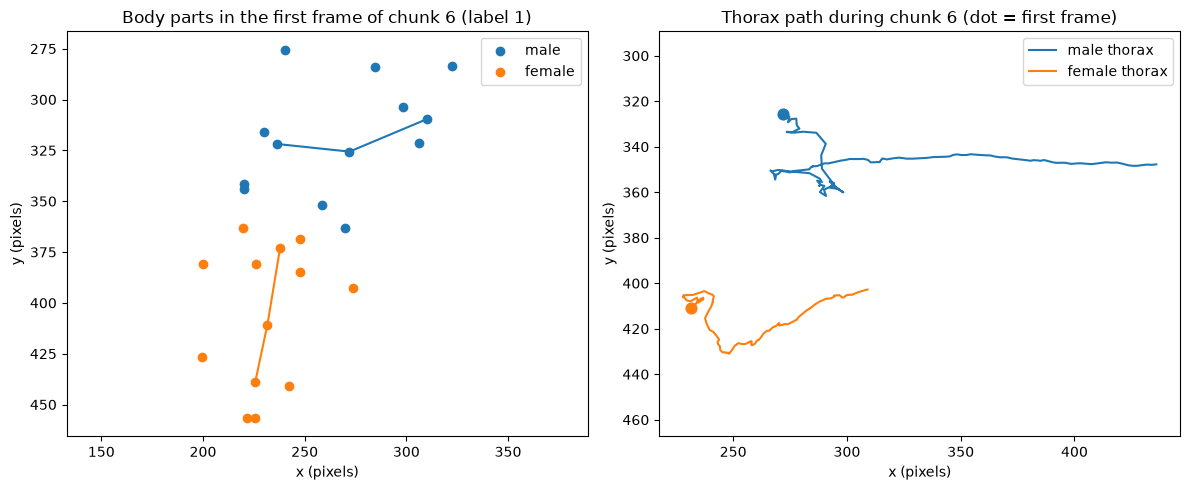

In [ ]:
chunk_id = 6      # change this number to look at other chunks
one_chunk = train[train["chunk"] == chunk_id]
frame = one_chunk.iloc[0]
colors = {"M": "tab:blue", "F": "tab:orange"}
names = {"M": "male", "F": "female"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for fly in ["M", "F"]:
    xs = [frame[f"{fly}_X_{bp}"] for bp in body_parts]
    ys = [frame[f"{fly}_Y_{bp}"] for bp in body_parts]
    axes[0].scatter(xs, ys, color=colors[fly], label=names[fly])
    axes[0].plot([frame[f"{fly}_X_{bp}"] for bp in ["head", "thorax", "abdomen"]],
                 [frame[f"{fly}_Y_{bp}"] for bp in ["head", "thorax", "abdomen"]],
                 color=colors[fly])            # body axis: head - thorax - abdomen
    axes[1].plot(one_chunk[f"{fly}_X_thorax"], one_chunk[f"{fly}_Y_thorax"],
                 color=colors[fly], label=f"{names[fly]} thorax")
    axes[1].scatter(one_chunk[f"{fly}_X_thorax"].iloc[0], one_chunk[f"{fly}_Y_thorax"].iloc[0],
                    color=colors[fly], marker="o", s=60)     # start of the chunk

axes[0].set_title(f"Body parts in the first frame of chunk {chunk_id} (label {frame['Label']:.0f})")
axes[1].set_title(f"Thorax path during chunk {chunk_id} (dot = first frame)")
for ax in axes:
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_aspect("equal", adjustable="datalim")
    ax.invert_yaxis()
    ax.legend()
plt.tight_layout()
plt.show()

Try other values of `chunk_id` (in some chunks the flies hardly move), and compare chunks with label 0 and label 1.
What differences can you see by eye? This is a good starting point for your features (Task 2).

## 5. Checking your prediction files (Task 7)

**What each file should look like, in words:** a plain csv file with a header row and a **single column named `prediction`**, with the value 0 or 1 on every row, in the **same order as `blind_test.csv.gz`**. Nothing else: no row numbers, no feature columns. The first lines look like this:

```
prediction
0
1
1
```

`blind_test_prediction.csv` has 120,000 such rows (one per row of the blind test set) and `blind_test_short_prediction.csv` has 800 (one per chunk).
Example of saving a file in the right format, where `chunk_predictions` is your array of 800 predictions:

```python
pd.DataFrame({"prediction": chunk_predictions}).to_csv("blind_test_short_prediction.csv", index=False)
```

Before you submit, run the function below on both files. It reports **problems** (fix these before you submit; each message says how) and **warnings** (usually fine, but have a look). It does **not** tell you your accuracy.
If it reports a problem that you cannot fix, submit anyway and write a sentence about it in your notebook or in an email to us.


In [ ]:
def check_prediction_file(path, expected_rows):
    """Check the format of a blind-test prediction file.

    Prints PROBLEMS (fix these before you submit) and WARNINGS (usually fine, but look).
    It does not tell you your accuracy.
    """
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"{path}: file not found. Did you save it, and in the current folder?")
        return
    problems, warnings = [], []
    cols = list(df.columns)
    index_cols = [c for c in cols if str(c).startswith("Unnamed")]
    if index_cols:
        warnings.append("the file has a row-number column (you saved the index). "
                        "Save it with to_csv(..., index=False).")

    def looks_like_number(c):
        return str(c).replace(".", "", 1).strip("-").isdigit()

    if "prediction" not in cols:
        named = [c for c in cols if c not in index_cols]
        if named and all(looks_like_number(c) for c in named):
            problems.append("the file has no header row, so the first prediction is read as the column name. "
                            "Save it with pd.DataFrame({'prediction': your_predictions}).to_csv(path, index=False).")
        else:
            problems.append(f"no column named 'prediction' (columns found: {cols}). "
                            "Rename the column with your predictions to 'prediction'.")
        values = None
    else:
        values = pd.to_numeric(df["prediction"], errors="coerce")
        n_bad = int(values.isna().sum())
        if n_bad:
            problems.append(f"{n_bad:,} predictions are missing or are not numbers.")
        other = sorted(float(v) for v in set(values.dropna().unique()) - {0, 1})
        if other:
            problems.append(f"'prediction' must contain only 0 and 1, but also contains {other[:10]}.")
        extra = [c for c in cols if c != "prediction" and c not in index_cols]
        if extra:
            warnings.append(f"extra columns {extra} will be ignored; the file only needs 'prediction'.")
        if values.nunique() == 1:
            warnings.append("all predictions are the same value.")

    if len(df) != expected_rows:
        msg = f"{len(df):,} rows, expected {expected_rows:,}."
        if len(df) in (expected_rows * 150, expected_rows // 150):
            msg += " This looks like the other prediction file (one per row vs. one per chunk)."
        elif len(df) == expected_rows - 1:
            msg += " One row is missing: is the header row missing?"
        problems.append(msg)

    _report(path, problems, warnings,
            ok_text=None if values is None else
            f"{len(df):,} rows; {(values == 1).mean():.1%} predicted as label 1")


def _report(path, problems, warnings, ok_text):
    if problems:
        print(f"{path}: PROBLEMS FOUND - please fix before you submit")
        for p in problems:
            print("  - PROBLEM:", p)
    else:
        print(f"{path}: OK ({ok_text})")
    for w in warnings:
        print("  - warning:", w)


# Uncomment when your files exist:
# check_prediction_file("blind_test_prediction.csv", expected_rows=len(blind_test))                  # 120,000
# check_prediction_file("blind_test_short_prediction.csv", expected_rows=blind_test["chunk"].nunique())  # 800
